In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib

In [28]:
FILE_PATH = "week4_ops_risp_analysis.csv"

df = pd.read_csv(FILE_PATH, encoding="utf-8-sig")

print("データ行数:", len(df))
print("列名一覧:")
print(df.columns.tolist())

df.head()

データ行数: 25
列名一覧:
['球団', '打者名', 'PA', '打点合計', 'RE24合計', 'WPA合計', '打点/PA', 'RE24/PA', 'WPA/PA', '打点順位', 'RE24順位', 'WPA順位', '打点/PA順位', 'RE24/PA順位', 'WPA/PA順位', 'WPA評価上昇', 'タイプ', 'OPS', 'OBP', 'SLG', 'AB', 'H', 'TB', 'BB', 'HBP', 'SF', '得点圏PA', '得点圏OPS', '得点圏OBP', '得点圏SLG']


,球団,打者名,PA,打点合計,RE24合計,WPA合計,打点/PA,RE24/PA,WPA/PA,打点順位,...,AB,H,TB,BB,HBP,SF,得点圏PA,得点圏OPS,得点圏OBP,得点圏SLG
0,阪神,佐藤 輝明,544,91,47.723,3.238965,0.167279,0.087726,0.005954,1,...,487,137,282,55,0,2,169,1.032164,0.396450,0.635714
1,西武,ネビン,491,54,21.654,0.468037,0.109980,0.044102,0.000953,2,...,439,122,200,41,8,3,120,0.829255,0.425000,0.404255
2,中日,細川 成也,313,43,19.930,3.654191,0.137380,0.063674,0.011675,5,...,266,68,130,42,3,2,94,0.907851,0.414894,0.492958
3,オリックス,杉本 裕太郎,308,29,-8.236,0.965217,0.094156,-0.026740,0.003134,10,...,270,62,97,29,5,4,94,0.508399,0.297872,0.210526
4,ソフトバンク,山川 穂高,289,35,0.287,0.849737,0.121107,0.000993,0.002940,8,...,259,56,98,26,3,1,100,0.552353,0.270000,0.282353


In [29]:
use_cols = [
    "球団", "打者名", "タイプ", "PA",
    "打点合計", "RE24合計", "WPA合計",
    "打点/PA", "RE24/PA", "WPA/PA",
    "OPS", "得点圏OPS", "得点圏PA"
]

df[use_cols].head()

,球団,打者名,タイプ,PA,打点合計,RE24合計,WPA合計,打点/PA,RE24/PA,WPA/PA,OPS,得点圏OPS,得点圏PA
0,阪神,佐藤 輝明,総合型,544,91,47.723,3.238965,0.167279,0.087726,0.005954,0.931997,1.032164,169
1,西武,ネビン,得点貢献型,491,54,21.654,0.468037,0.109980,0.044102,0.000953,0.803850,0.829255,120
2,中日,細川 成也,総合型,313,43,19.930,3.654191,0.137380,0.063674,0.011675,0.849744,0.907851,94
3,オリックス,杉本 裕太郎,勝利貢献型,308,29,-8.236,0.965217,0.094156,-0.026740,0.003134,0.670948,0.508399,94
4,ソフトバンク,山川 穂高,その他,289,35,0.287,0.849737,0.121107,0.000993,0.002940,0.672496,0.552353,100


In [30]:
check_cols = [
    "PA", "打点合計", "RE24合計", "WPA合計",
    "打点/PA", "RE24/PA", "WPA/PA",
    "OPS", "得点圏OPS", "得点圏PA"
]

print(df[check_cols].isna().sum())

PA         0
打点合計       0
RE24合計     0
WPA合計      0
打点/PA      0
RE24/PA    0
WPA/PA     0
OPS        0
得点圏OPS     0
得点圏PA      0
dtype: int64


In [31]:
analysis_df = df.copy()

# 必要な数値列を数値型に変換
for col in check_cols:
    analysis_df[col] = pd.to_numeric(analysis_df[col], errors="coerce")

# 得点圏OPSや得点圏PAがない選手を除く
analysis_df = analysis_df.dropna(subset=["得点圏OPS", "得点圏PA"])

print("分析対象人数:", len(analysis_df))

analysis_df[use_cols].head()

分析対象人数: 25


,球団,打者名,タイプ,PA,打点合計,RE24合計,WPA合計,打点/PA,RE24/PA,WPA/PA,OPS,得点圏OPS,得点圏PA
0,阪神,佐藤 輝明,総合型,544,91,47.723,3.238965,0.167279,0.087726,0.005954,0.931997,1.032164,169
1,西武,ネビン,得点貢献型,491,54,21.654,0.468037,0.109980,0.044102,0.000953,0.803850,0.829255,120
2,中日,細川 成也,総合型,313,43,19.930,3.654191,0.137380,0.063674,0.011675,0.849744,0.907851,94
3,オリックス,杉本 裕太郎,勝利貢献型,308,29,-8.236,0.965217,0.094156,-0.026740,0.003134,0.670948,0.508399,94
4,ソフトバンク,山川 穂高,その他,289,35,0.287,0.849737,0.121107,0.000993,0.002940,0.672496,0.552353,100


In [32]:
chance_corr_cols = [
    "得点圏PA",
    "打点合計",
    "RE24合計",
    "WPA合計",
    "RE24/PA",
    "WPA/PA",
    "得点圏OPS"
]

chance_corr = analysis_df[chance_corr_cols].corr()

chance_corr

,得点圏PA,打点合計,RE24合計,WPA合計,RE24/PA,WPA/PA,得点圏OPS
得点圏PA,1.000000,0.880150,0.545899,0.309580,0.132105,0.079552,0.021711
打点合計,0.880150,1.000000,0.856712,0.579202,0.551617,0.387856,0.401203
RE24合計,0.545899,0.856712,1.000000,0.700414,0.846425,0.568084,0.716274
WPA合計,0.309580,0.579202,0.700414,1.000000,0.767673,0.929460,0.642360
RE24/PA,0.132105,0.551617,0.846425,0.767673,1.000000,0.800105,0.885176
WPA/PA,0.079552,0.387856,0.568084,0.929460,0.800105,1.000000,0.726026
得点圏OPS,0.021711,0.401203,0.716274,0.642360,0.885176,0.726026,1.000000


In [33]:
risp_pa_corr = (
    chance_corr["得点圏PA"]
    .drop("得点圏PA")
    .sort_values(ascending=False)
    .reset_index()
)

risp_pa_corr.columns = ["指標", "得点圏PAとの相関"]

risp_pa_corr

,指標,得点圏PAとの相関
0,打点合計,0.880150
1,RE24合計,0.545899
2,WPA合計,0.309580
3,RE24/PA,0.132105
4,WPA/PA,0.079552
5,得点圏OPS,0.021711


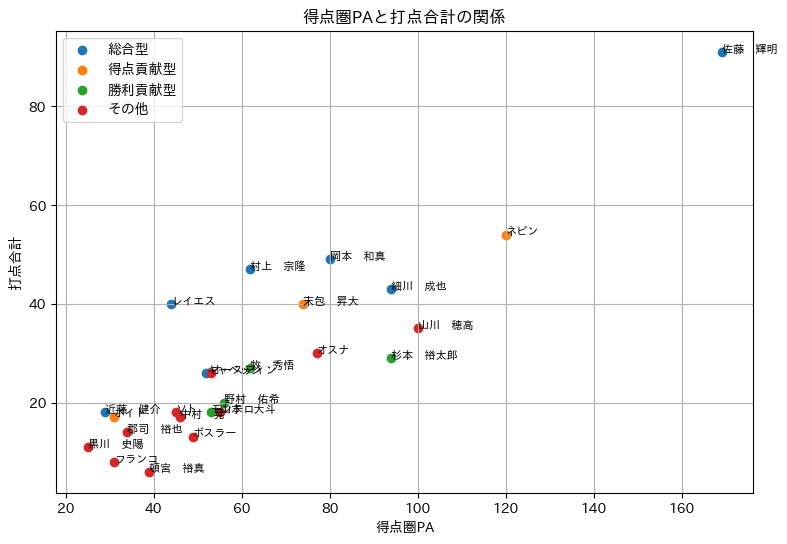

In [34]:
plt.figure(figsize=(9, 6))

for t in analysis_df["タイプ"].unique():
    data = analysis_df[analysis_df["タイプ"] == t]
    plt.scatter(data["得点圏PA"], data["打点合計"], label=t)

for _, row in analysis_df.iterrows():
    plt.text(row["得点圏PA"], row["打点合計"], row["打者名"], fontsize=8)

plt.xlabel("得点圏PA")
plt.ylabel("打点合計")
plt.title("得点圏PAと打点合計の関係")
plt.legend()
plt.grid(True)
plt.show()

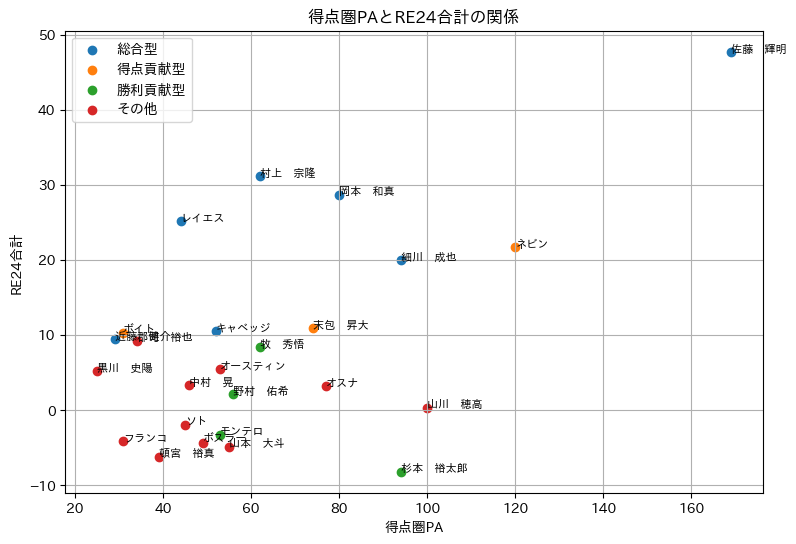

In [35]:
plt.figure(figsize=(9, 6))

for t in analysis_df["タイプ"].unique():
    data = analysis_df[analysis_df["タイプ"] == t]
    plt.scatter(data["得点圏PA"], data["RE24合計"], label=t)

for _, row in analysis_df.iterrows():
    plt.text(row["得点圏PA"], row["RE24合計"], row["打者名"], fontsize=8)

plt.xlabel("得点圏PA")
plt.ylabel("RE24合計")
plt.title("得点圏PAとRE24合計の関係")
plt.legend()
plt.grid(True)
plt.show()

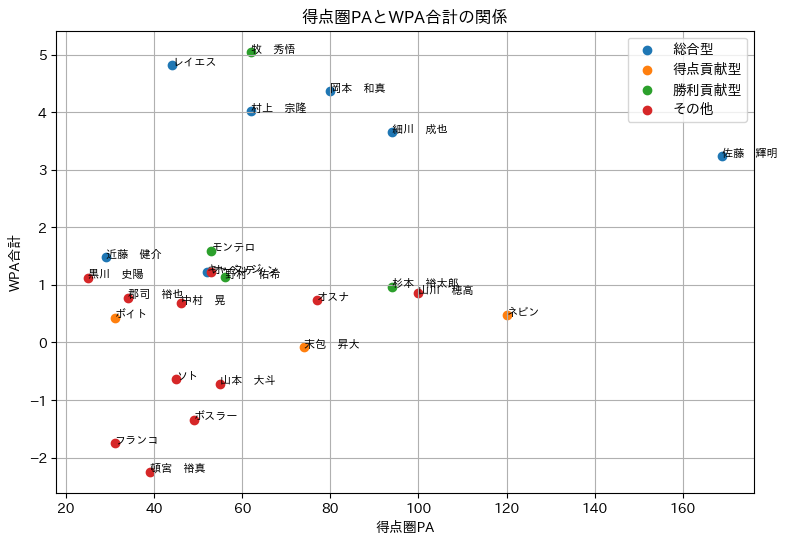

In [36]:
plt.figure(figsize=(9, 6))

for t in analysis_df["タイプ"].unique():
    data = analysis_df[analysis_df["タイプ"] == t]
    plt.scatter(data["得点圏PA"], data["WPA合計"], label=t)

for _, row in analysis_df.iterrows():
    plt.text(row["得点圏PA"], row["WPA合計"], row["打者名"], fontsize=8)

plt.xlabel("得点圏PA")
plt.ylabel("WPA合計")
plt.title("得点圏PAとWPA合計の関係")
plt.legend()
plt.grid(True)
plt.show()

In [37]:
risp_ops_corr_cols = [
    "得点圏OPS",
    "打点合計",
    "RE24合計",
    "WPA合計",
    "RE24/PA",
    "WPA/PA",
    "OPS",
    "得点圏PA"
]

risp_ops_corr = analysis_df[risp_ops_corr_cols].corr()

risp_ops_corr

,得点圏OPS,打点合計,RE24合計,WPA合計,RE24/PA,WPA/PA,OPS,得点圏PA
得点圏OPS,1.000000,0.401203,0.716274,0.642360,0.885176,0.726026,0.704667,0.021711
打点合計,0.401203,1.000000,0.856712,0.579202,0.551617,0.387856,0.596070,0.880150
RE24合計,0.716274,0.856712,1.000000,0.700414,0.846425,0.568084,0.846293,0.545899
WPA合計,0.642360,0.579202,0.700414,1.000000,0.767673,0.929460,0.770399,0.309580
RE24/PA,0.885176,0.551617,0.846425,0.767673,1.000000,0.800105,0.925784,0.132105
WPA/PA,0.726026,0.387856,0.568084,0.929460,0.800105,1.000000,0.725045,0.079552
OPS,0.704667,0.596070,0.846293,0.770399,0.925784,0.725045,1.000000,0.223742
得点圏PA,0.021711,0.880150,0.545899,0.309580,0.132105,0.079552,0.223742,1.000000


In [38]:
risp_ops_corr_summary = (
    risp_ops_corr["得点圏OPS"]
    .drop("得点圏OPS")
    .sort_values(ascending=False)
    .reset_index()
)

risp_ops_corr_summary.columns = ["指標", "得点圏OPSとの相関"]

risp_ops_corr_summary

,指標,得点圏OPSとの相関
0,RE24/PA,0.885176
1,WPA/PA,0.726026
2,RE24合計,0.716274
3,OPS,0.704667
4,WPA合計,0.642360
5,打点合計,0.401203
6,得点圏PA,0.021711


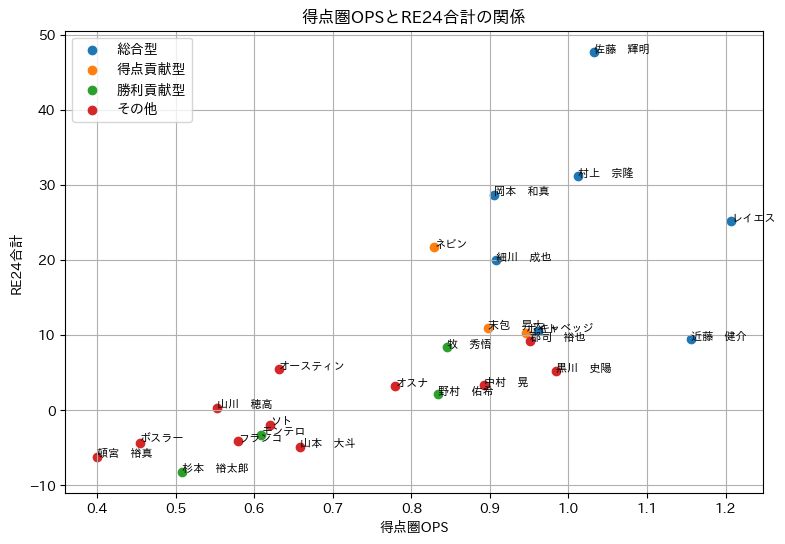

In [39]:
plt.figure(figsize=(9, 6))

for t in analysis_df["タイプ"].unique():
    data = analysis_df[analysis_df["タイプ"] == t]
    plt.scatter(data["得点圏OPS"], data["RE24合計"], label=t)

for _, row in analysis_df.iterrows():
    plt.text(row["得点圏OPS"], row["RE24合計"], row["打者名"], fontsize=8)

plt.xlabel("得点圏OPS")
plt.ylabel("RE24合計")
plt.title("得点圏OPSとRE24合計の関係")
plt.legend()
plt.grid(True)
plt.show()

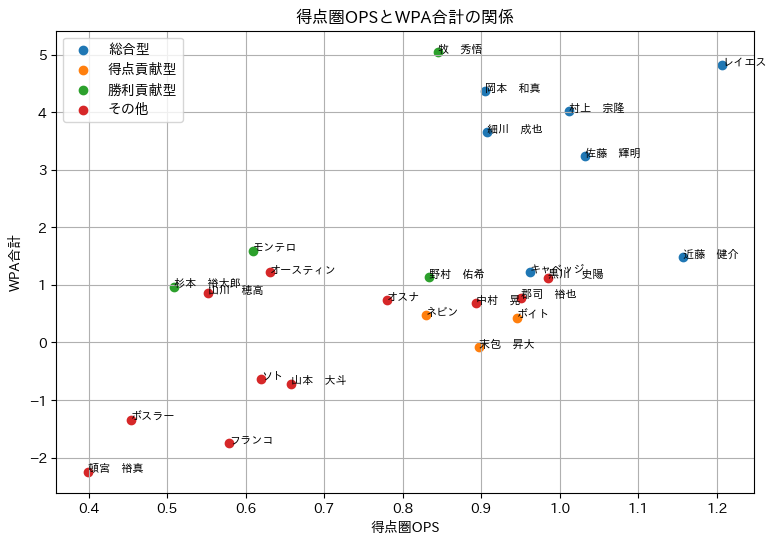

In [40]:
plt.figure(figsize=(9, 6))

for t in analysis_df["タイプ"].unique():
    data = analysis_df[analysis_df["タイプ"] == t]
    plt.scatter(data["得点圏OPS"], data["WPA合計"], label=t)

for _, row in analysis_df.iterrows():
    plt.text(row["得点圏OPS"], row["WPA合計"], row["打者名"], fontsize=8)

plt.xlabel("得点圏OPS")
plt.ylabel("WPA合計")
plt.title("得点圏OPSとWPA合計の関係")
plt.legend()
plt.grid(True)
plt.show()

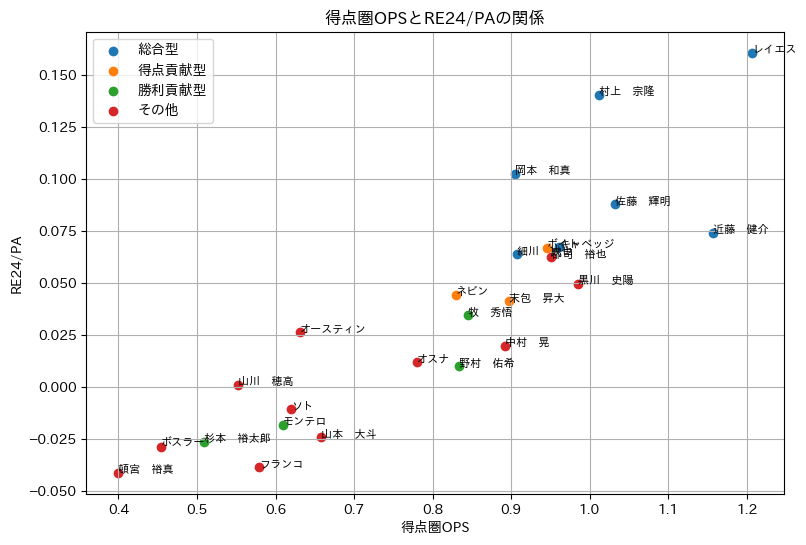

In [41]:
plt.figure(figsize=(9, 6))

for t in analysis_df["タイプ"].unique():
    data = analysis_df[analysis_df["タイプ"] == t]
    plt.scatter(data["得点圏OPS"], data["RE24/PA"], label=t)

for _, row in analysis_df.iterrows():
    plt.text(row["得点圏OPS"], row["RE24/PA"], row["打者名"], fontsize=8)

plt.xlabel("得点圏OPS")
plt.ylabel("RE24/PA")
plt.title("得点圏OPSとRE24/PAの関係")
plt.legend()
plt.grid(True)
plt.show()

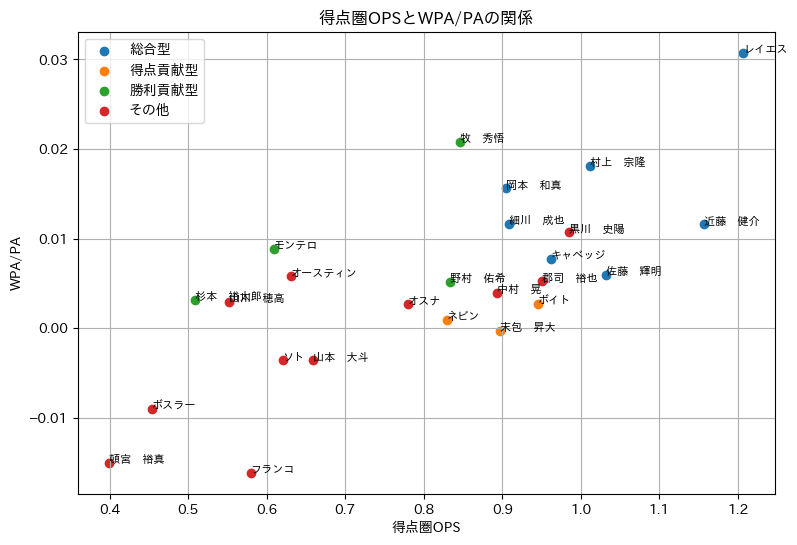

In [42]:
plt.figure(figsize=(9, 6))

for t in analysis_df["タイプ"].unique():
    data = analysis_df[analysis_df["タイプ"] == t]
    plt.scatter(data["得点圏OPS"], data["WPA/PA"], label=t)

for _, row in analysis_df.iterrows():
    plt.text(row["得点圏OPS"], row["WPA/PA"], row["打者名"], fontsize=8)

plt.xlabel("得点圏OPS")
plt.ylabel("WPA/PA")
plt.title("得点圏OPSとWPA/PAの関係")
plt.legend()
plt.grid(True)
plt.show()

In [43]:
median_risp_pa = analysis_df["得点圏PA"].median()
median_risp_ops = analysis_df["得点圏OPS"].median()

print("得点圏PAの中央値:", median_risp_pa)
print("得点圏OPSの中央値:", median_risp_ops)

得点圏PAの中央値: 53.0
得点圏OPSの中央値: 0.8455334987593052


In [44]:
def classify_chance_type(row):
    risp_pa = row["得点圏PA"]
    risp_ops = row["得点圏OPS"]

    if risp_pa >= median_risp_pa and risp_ops >= median_risp_ops:
        return "チャンス多・成果高"
    elif risp_pa >= median_risp_pa and risp_ops < median_risp_ops:
        return "チャンス多・成果低"
    elif risp_pa < median_risp_pa and risp_ops >= median_risp_ops:
        return "チャンス少・成果高"
    else:
        return "チャンス少・成果低"


analysis_df["チャンスタイプ"] = analysis_df.apply(classify_chance_type, axis=1)

analysis_df[
    ["球団", "打者名", "タイプ", "PA", "得点圏PA", "得点圏OPS",
     "打点合計", "RE24合計", "WPA合計", "RE24/PA", "WPA/PA", "チャンスタイプ"]
].sort_values(["チャンスタイプ", "得点圏OPS"], ascending=[True, False])

,球団,打者名,タイプ,PA,得点圏PA,得点圏OPS,打点合計,RE24合計,WPA合計,RE24/PA,WPA/PA,チャンスタイプ
10,日本ハム,野村 佑希,勝利貢献型,218,56,0.833333,20,2.118,1.132902,0.009716,0.005197,チャンス多・成果低
1,西武,ネビン,得点貢献型,491,120,0.829255,54,21.654,0.468037,0.044102,0.000953,チャンス多・成果低
6,ヤクルト,オスナ,その他,273,77,0.779647,30,3.214,0.736590,0.011773,0.002698,チャンス多・成果低
12,ロッテ,山本 大斗,その他,201,55,0.658256,18,-4.906,-0.718523,-0.024408,-0.003575,チャンス多・成果低
11,DeNA,オースティン,その他,210,53,0.630845,26,5.493,1.218329,0.026157,0.005802,チャンス多・成果低
13,広島,モンテロ,勝利貢献型,180,53,0.609106,18,-3.287,1.595811,-0.018261,0.008866,チャンス多・成果低
4,ソフトバンク,山川 穂高,その他,289,100,0.552353,35,0.287,0.849737,0.000993,0.002940,チャンス多・成果低
3,オリックス,杉本 裕太郎,勝利貢献型,308,94,0.508399,29,-8.236,0.965217,-0.026740,0.003134,チャンス多・成果低
0,阪神,佐藤 輝明,総合型,544,169,1.032164,91,47.723,3.238965,0.087726,0.005954,チャンス多・成果高
9,ヤクルト,村上 宗隆,総合型,222,62,1.011921,47,31.171,4.020346,0.140410,0.018110,チャンス多・成果高


In [45]:
chance_type_count = analysis_df["チャンスタイプ"].value_counts().reset_index()
chance_type_count.columns = ["チャンスタイプ", "人数"]

chance_type_count

,チャンスタイプ,人数
0,チャンス多・成果低,8
1,チャンス少・成果高,7
2,チャンス多・成果高,6
3,チャンス少・成果低,4


In [46]:
chance_type_summary = (
    analysis_df.groupby("チャンスタイプ")
    .agg(
        人数=("チャンスタイプ", "count"),
        平均得点圏PA=("得点圏PA", "mean"),
        平均得点圏OPS=("得点圏OPS", "mean"),
        平均打点=("打点合計", "mean"),
        平均RE24=("RE24合計", "mean"),
        平均WPA=("WPA合計", "mean"),
        平均RE24_PA=("RE24/PA", "mean"),
        平均WPA_PA=("WPA/PA", "mean")
    )
    .reset_index()
)

chance_type_summary

,チャンスタイプ,人数,平均得点圏PA,平均得点圏OPS,平均打点,平均RE24,平均WPA,平均RE24_PA,平均WPA_PA
0,チャンス多・成果低,8,76.000000,0.675149,28.750000,2.042125,0.781012,0.002916,0.003252
1,チャンス多・成果高,6,90.166667,0.933248,49.500000,24.460500,3.375647,0.078241,0.011972
2,チャンス少・成果低,4,41.000000,0.513352,11.250000,-4.174000,-1.494693,-0.030006,-0.010920
3,チャンス少・成果高,7,37.285714,1.014087,20.428571,10.461857,1.503664,0.071376,0.010390


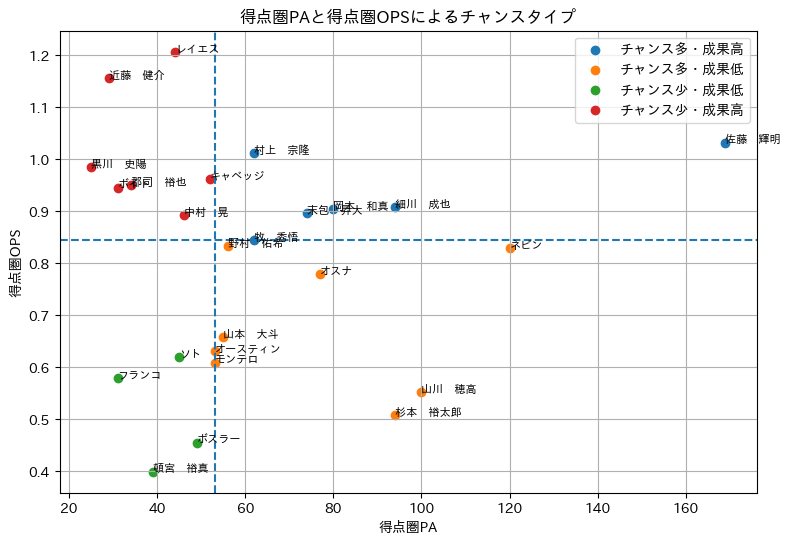

In [47]:
plt.figure(figsize=(9, 6))

for t in analysis_df["チャンスタイプ"].unique():
    data = analysis_df[analysis_df["チャンスタイプ"] == t]
    plt.scatter(data["得点圏PA"], data["得点圏OPS"], label=t)

for _, row in analysis_df.iterrows():
    plt.text(row["得点圏PA"], row["得点圏OPS"], row["打者名"], fontsize=8)

plt.axvline(median_risp_pa, linestyle="--")
plt.axhline(median_risp_ops, linestyle="--")

plt.xlabel("得点圏PA")
plt.ylabel("得点圏OPS")
plt.title("得点圏PAと得点圏OPSによるチャンスタイプ")
plt.legend()
plt.grid(True)
plt.show()

In [48]:
analysis_df.sort_values("得点圏PA", ascending=False)[
    ["球団", "打者名", "タイプ", "チャンスタイプ",
     "PA", "得点圏PA", "得点圏OPS",
     "打点合計", "RE24合計", "WPA合計", "RE24/PA", "WPA/PA"]
].head(15)

,球団,打者名,タイプ,チャンスタイプ,PA,得点圏PA,得点圏OPS,打点合計,RE24合計,WPA合計,RE24/PA,WPA/PA
0,阪神,佐藤 輝明,総合型,チャンス多・成果高,544,169,1.032164,91,47.723,3.238965,0.087726,0.005954
1,西武,ネビン,得点貢献型,チャンス多・成果低,491,120,0.829255,54,21.654,0.468037,0.044102,0.000953
4,ソフトバンク,山川 穂高,その他,チャンス多・成果低,289,100,0.552353,35,0.287,0.849737,0.000993,0.002940
2,中日,細川 成也,総合型,チャンス多・成果高,313,94,0.907851,43,19.930,3.654191,0.063674,0.011675
3,オリックス,杉本 裕太郎,勝利貢献型,チャンス多・成果低,308,94,0.508399,29,-8.236,0.965217,-0.026740,0.003134
5,巨人,岡本 和真,総合型,チャンス多・成果高,280,80,0.904808,49,28.686,4.366410,0.102450,0.015594
6,ヤクルト,オスナ,その他,チャンス多・成果低,273,77,0.779647,30,3.214,0.736590,0.011773,0.002698
7,広島,末包 昇大,得点貢献型,チャンス多・成果高,267,74,0.897209,40,10.932,-0.075041,0.040944,-0.000281
8,DeNA,牧 秀悟,勝利貢献型,チャンス多・成果高,243,62,0.845533,27,8.321,5.049012,0.034243,0.020778
9,ヤクルト,村上 宗隆,総合型,チャンス多・成果高,222,62,1.011921,47,31.171,4.020346,0.140410,0.018110


In [49]:
analysis_df.sort_values("得点圏OPS", ascending=False)[
    ["球団", "打者名", "タイプ", "チャンスタイプ",
     "PA", "得点圏PA", "得点圏OPS",
     "打点合計", "RE24合計", "WPA合計", "RE24/PA", "WPA/PA"]
].head(15)

,球団,打者名,タイプ,チャンスタイプ,PA,得点圏PA,得点圏OPS,打点合計,RE24合計,WPA合計,RE24/PA,WPA/PA
17,日本ハム,レイエス,総合型,チャンス少・成果高,157,44,1.207002,40,25.210,4.825634,0.160573,0.030737
22,ソフトバンク,近藤 健介,総合型,チャンス少・成果高,128,29,1.156609,18,9.484,1.482278,0.074094,0.011580
0,阪神,佐藤 輝明,総合型,チャンス多・成果高,544,169,1.032164,91,47.723,3.238965,0.087726,0.005954
9,ヤクルト,村上 宗隆,総合型,チャンス多・成果高,222,62,1.011921,47,31.171,4.020346,0.140410,0.018110
24,楽天,黒川 史陽,その他,チャンス少・成果高,105,25,0.984649,11,5.203,1.124762,0.049552,0.010712
16,巨人,キャベッジ,総合型,チャンス少・成果高,157,52,0.961538,26,10.538,1.219419,0.067121,0.007767
21,日本ハム,郡司 裕也,その他,チャンス少・成果高,148,34,0.950588,14,9.203,0.776498,0.062182,0.005247
18,楽天,ボイト,得点貢献型,チャンス少・成果高,154,31,0.945409,17,10.230,0.418691,0.066429,0.002719
2,中日,細川 成也,総合型,チャンス多・成果高,313,94,0.907851,43,19.930,3.654191,0.063674,0.011675
5,巨人,岡本 和真,総合型,チャンス多・成果高,280,80,0.904808,49,28.686,4.366410,0.102450,0.015594


In [50]:
analysis_df[analysis_df["チャンスタイプ"] == "チャンス少・成果高"][
    ["球団", "打者名", "タイプ", "チャンスタイプ",
     "PA", "得点圏PA", "得点圏OPS",
     "打点合計", "RE24合計", "WPA合計", "RE24/PA", "WPA/PA"]
].sort_values("得点圏OPS", ascending=False)

,球団,打者名,タイプ,チャンスタイプ,PA,得点圏PA,得点圏OPS,打点合計,RE24合計,WPA合計,RE24/PA,WPA/PA
17,日本ハム,レイエス,総合型,チャンス少・成果高,157,44,1.207002,40,25.210,4.825634,0.160573,0.030737
22,ソフトバンク,近藤 健介,総合型,チャンス少・成果高,128,29,1.156609,18,9.484,1.482278,0.074094,0.011580
24,楽天,黒川 史陽,その他,チャンス少・成果高,105,25,0.984649,11,5.203,1.124762,0.049552,0.010712
16,巨人,キャベッジ,総合型,チャンス少・成果高,157,52,0.961538,26,10.538,1.219419,0.067121,0.007767
21,日本ハム,郡司 裕也,その他,チャンス少・成果高,148,34,0.950588,14,9.203,0.776498,0.062182,0.005247
18,楽天,ボイト,得点貢献型,チャンス少・成果高,154,31,0.945409,17,10.230,0.418691,0.066429,0.002719
15,ソフトバンク,中村 晃,その他,チャンス少・成果高,171,46,0.892810,17,3.365,0.678367,0.019678,0.003967


In [51]:
analysis_df[analysis_df["チャンスタイプ"] == "チャンス多・成果高"][
    ["球団", "打者名", "タイプ", "チャンスタイプ",
     "PA", "得点圏PA", "得点圏OPS",
     "打点合計", "RE24合計", "WPA合計", "RE24/PA", "WPA/PA"]
].sort_values("RE24合計", ascending=False)

,球団,打者名,タイプ,チャンスタイプ,PA,得点圏PA,得点圏OPS,打点合計,RE24合計,WPA合計,RE24/PA,WPA/PA
0,阪神,佐藤 輝明,総合型,チャンス多・成果高,544,169,1.032164,91,47.723,3.238965,0.087726,0.005954
9,ヤクルト,村上 宗隆,総合型,チャンス多・成果高,222,62,1.011921,47,31.171,4.020346,0.140410,0.018110
5,巨人,岡本 和真,総合型,チャンス多・成果高,280,80,0.904808,49,28.686,4.366410,0.102450,0.015594
2,中日,細川 成也,総合型,チャンス多・成果高,313,94,0.907851,43,19.930,3.654191,0.063674,0.011675
7,広島,末包 昇大,得点貢献型,チャンス多・成果高,267,74,0.897209,40,10.932,-0.075041,0.040944,-0.000281
8,DeNA,牧 秀悟,勝利貢献型,チャンス多・成果高,243,62,0.845533,27,8.321,5.049012,0.034243,0.020778


In [52]:
analysis_df.to_csv("week5_chance_analysis.csv", index=False, encoding="utf-8-sig")
chance_type_summary.to_csv("week5_chance_type_summary.csv", index=False, encoding="utf-8-sig")

print("保存完了")
print("week5_chance_analysis.csv")
print("week5_chance_type_summary.csv")

保存完了
week5_chance_analysis.csv
week5_chance_type_summary.csv
